# 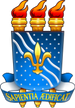
### Universidade Federal da Paraíba
##### Centro de Informática
##### Disciplina: Análise e Projeto de Algoritmos
##### Docente: Lucidio dos Anjos Formiga Cabral
##### Discente:
##### - Gabriel de Lucca Vieira

##### 22 de Abril de 2025

## Projeto Final - 2024.2

##### [Enunciado do projeto](https://sig-arq.ufpb.br/arquivos/2025008165d4c374052213b1913c176f6/Projeto_Final__2024_2__APA__Professor_Lucidio_Cabral.pdf)

In [1]:
# Importação das bibliotecas necessárias
from glob import glob  # Usado para buscar arquivos em diretórios com o padrão especificado
import numpy as np  # Biblioteca principal para manipulação de arrays e cálculos
from numpy import inf as INF  # Importa "inf" com o nome INF
from copy import deepcopy  # Usado para fazer cópias profundas dos objetos
import json

# Funções importadas de outros módulos
from functions.starters import read_instance, compute_total_cost as ctc, initial_solution
from functions.greedy_sol import greedy_initial_solution as gis
from metaheuristics.runaway_movements import neighbor_swap_in_runway as SWAP, neighbor_move_between_runways as MOVE, neighbor_reinsert_in_runway as REINSERT
from metaheuristics.vnd import VND
from metaheuristics.ils import ILS
from metaheuristics.grasp import GRASP
from metaheuristics.vns import VNS

In [2]:
# Definindo as funções de vizinhança para o VND e VNS
neighborhood_functions = [SWAP, MOVE, REINSERT]

# Número máximo de execuções para cada instância
MAX_EXECS = 500

# Criação do arquivo CSV onde os resultados serão salvos
dataset = open('../data/metaheuristics_dataset.csv', 'w', encoding='utf-8')
# Cabeçalho do arquivo CSV com as informações das métricas que serão registradas
print('Instance;Heuristic;Iterations;Average cost;Best cost;Average performance time(s);Best performance time(s);GAP(%);Average GAP(%)', file=dataset)

solutions_data = {}

In [3]:
# Laço para iterar sobre todas as instâncias de problemas nos arquivos da pasta 'instances'
for instance_filepath in glob('../instances/*'):
    # Lendo os dados da instância (número de voos, número de pistas, tempos de liberação, ocupação, penalidades, e separações)
    N_VOOS, M_RUNAWAYS, R, C, P, T = read_instance(instance_filepath)
    
    # Nome da instância extraído do caminho do arquivo
    instance = instance_filepath.split('instances\\')[-1].split('.txt')[0]
    
    # Solução inicial gerada pela heurística construtiva
    INITIAL_SOLUTION, IS_PERF_TIME = initial_solution(N_VOOS, M_RUNAWAYS, R)
    INITIAL_SOLUTION_COST = ctc(INITIAL_SOLUTION, R, C, P, T)
    
    # Solução gerada pela heurística gulosa (Greedy)
    GREEDY_SOLUTION, GS_PERF_TIME = gis(N_VOOS, M_RUNAWAYS, R, T)
    GREEDY_SOLUTION_COST = ctc(GREEDY_SOLUTION, R, C, P, T)
    
    # Armazenando a melhor solução inicial
    BEST_INITIAL_SOLUTIONS = {}
    BEST_INITIAL_SOLUTIONS[INITIAL_SOLUTION_COST] = deepcopy(INITIAL_SOLUTION)
    BEST_INITIAL_SOLUTIONS[GREEDY_SOLUTION_COST] = deepcopy(GREEDY_SOLUTION)
    
    # Ordenando as soluções iniciais para pegar a melhor e a segunda melhor
    BEST, SECOND_BEST = sorted(BEST_INITIAL_SOLUTIONS.keys())
    
    # Executando a metaheurística GRASP
    GRASP_SOLUTION, GRASP_COST, GRASP_ITERATIONS, GRASP_PERF_TIME = GRASP(N_VOOS, M_RUNAWAYS, R, C, P, T, ILS, neighborhood_functions, VND)
    
    # Preparando os dicionários para armazenar as melhores soluções dos algoritmos
    BEST_VND_SOLUTIONS = {}
    BEST_VND_SOLUTIONS[INF] = None
    BEST_VND_SOLUTIONS[SECOND_BEST] = deepcopy(BEST_INITIAL_SOLUTIONS[SECOND_BEST])
    
    BEST_VND = deepcopy(BEST_INITIAL_SOLUTIONS[BEST])
    S_BEST_VND = deepcopy(BEST_INITIAL_SOLUTIONS[SECOND_BEST])
    
    BEST_ILS_SOLUTIONS = {}
    BEST_ILS_SOLUTIONS[INF] = None
    BEST_ILS_SOLUTIONS[SECOND_BEST] = deepcopy(BEST_INITIAL_SOLUTIONS[SECOND_BEST])
    
    BEST_ILS = deepcopy(BEST_INITIAL_SOLUTIONS[BEST])
    S_BEST_ILS = deepcopy(BEST_INITIAL_SOLUTIONS[SECOND_BEST])
    
    BEST_VNS_SOLUTIONS = {}
    BEST_VNS_SOLUTIONS[INF] = None
    BEST_VNS_SOLUTIONS[SECOND_BEST] = deepcopy(BEST_INITIAL_SOLUTIONS[SECOND_BEST])
    
    BEST_VNS = deepcopy(BEST_INITIAL_SOLUTIONS[BEST])
    S_BEST_VNS = deepcopy(BEST_INITIAL_SOLUTIONS[SECOND_BEST])
    
    # Listas para armazenar os tempos de execução dos algoritmos
    VND_PERF_TIMES_LIST = []
    ILS_PERF_TIMES_LIST = []
    VNS_PERF_TIMES_LIST = []

    # Laço principal para executar as meta-heurísticas (VND, ILS, VNS) várias vezes
    for _ in range(MAX_EXECS):
        # Executando o algoritmo VND em duas soluções (melhor e segunda melhor)
        VND_SOLUTION1, VND_COST1, VND_ITERATIONS1, VND_PERF_TIME1 = VND(BEST_VND, R, C, P, T, ctc, neighborhood_functions)
        VND_SOLUTION2, VND_COST2, VND_ITERATIONS2, VND_PERF_TIME2 = VND(S_BEST_VND, R, C, P, T, ctc, neighborhood_functions)
        
        VND_PERF_TIMES_LIST += [VND_PERF_TIME1, VND_PERF_TIME2]
        
        # Atualizando as melhores soluções encontradas pelo VND
        B, SB = sorted(BEST_VND_SOLUTIONS.keys())[:2]
        if(VND_COST1 < B):
            BEST_VND_SOLUTIONS[VND_COST1] = deepcopy(VND_SOLUTION1)
            VND_ITERATIONS = VND_ITERATIONS1
            VND_BEST_PERF_TIME = VND_PERF_TIME1
        elif(VND_COST1 <= SB):
            BEST_VND_SOLUTIONS[VND_COST1] = deepcopy(VND_SOLUTION1)
        
        B, SB = sorted(BEST_VND_SOLUTIONS.keys())[:2]
        if(VND_COST2 < B):
            BEST_VND_SOLUTIONS[VND_COST2] = deepcopy(VND_SOLUTION2)
            VND_ITERATIONS = VND_ITERATIONS2
            VND_BEST_PERF_TIME = VND_PERF_TIME2
        elif(VND_COST2 <= SB):
            BEST_VND_SOLUTIONS[VND_COST2] = deepcopy(VND_SOLUTION2)

        # Atualizando a melhor solução VND
        VND_COSTS = np.array(sorted([k for k in BEST_VND_SOLUTIONS.keys() if k != INF]))
        BEST_VND_COST, S_BEST_VND_COST = VND_COSTS[:2]
        BEST_VND = deepcopy(BEST_VND_SOLUTIONS[BEST_VND_COST])
        S_BEST_VND = deepcopy(BEST_VND_SOLUTIONS[S_BEST_VND_COST])
        
        # Executando ILS com a melhor solução do VND
        BEST_ILS_SOLUTIONS[BEST_VND_COST] = deepcopy(BEST_VND)
        BEST_ILS_SOLUTIONS[S_BEST_VND_COST] = deepcopy(S_BEST_VND)
        
        ILS_SOLUTION1, ILS_COST1, ILS_ITERATIONS1, ILS_PERF_TIME1 = ILS(BEST_ILS, R, C, P, T, ctc, neighborhood_functions, VND)
        ILS_SOLUTION2, ILS_COST2, ILS_ITERATIONS2, ILS_PERF_TIME2 = ILS(S_BEST_ILS, R, C, P, T, ctc, neighborhood_functions, VND)
        
        ILS_PERF_TIMES_LIST += [ILS_PERF_TIME1, ILS_PERF_TIME2]
        
        # Atualizando as melhores soluções encontradas pelo ILS
        B, SB = sorted(BEST_ILS_SOLUTIONS.keys())[:2]
        if(ILS_COST1 < B):
            BEST_ILS_SOLUTIONS[ILS_COST1] = deepcopy(ILS_SOLUTION1)
            ILS_ITERATIONS = ILS_ITERATIONS1
            ILS_BEST_PERF_TIME = ILS_PERF_TIME1
        elif(ILS_COST1 <= SB):
            BEST_ILS_SOLUTIONS[ILS_COST1] = deepcopy(ILS_SOLUTION1)
        
        B, SB = sorted(BEST_ILS_SOLUTIONS.keys())[:2]
        if(ILS_COST2 < B):
            BEST_ILS_SOLUTIONS[ILS_COST2] = deepcopy(ILS_SOLUTION2)
            ILS_ITERATIONS = ILS_ITERATIONS2
            ILS_BEST_PERF_TIME = ILS_PERF_TIME2
        elif(ILS_COST2 <= SB):
           BEST_ILS_SOLUTIONS[ILS_COST2] = deepcopy(ILS_SOLUTION2)
        
        # Atualizando a melhor solução ILS
        ILS_COSTS = np.array(sorted([k for k in BEST_ILS_SOLUTIONS.keys() if k != INF]))
        BEST_ILS_COST, S_BEST_ILS_COST = ILS_COSTS[:2]
        BEST_ILS = deepcopy(BEST_ILS_SOLUTIONS[BEST_ILS_COST])
        S_BEST_ILS = deepcopy(BEST_ILS_SOLUTIONS[S_BEST_ILS_COST])
        
        # Executando VNS com a melhor solução de VND e ILS
        BEST_VNS_SOLUTIONS[BEST_VND_COST] = deepcopy(BEST_VND)
        BEST_VNS_SOLUTIONS[BEST_ILS_COST] = deepcopy(BEST_ILS)
        
        VNS_SOLUTION1, VNS_COST1, VNS_ITERATIONS1, VNS_PERF_TIME1 = VNS(BEST_VNS, R, C, P, T, ctc, neighborhood_functions)
        VNS_SOLUTION2, VNS_COST2, VNS_ITERATIONS2, VNS_PERF_TIME2 = VNS(S_BEST_VNS, R, C, P, T, ctc, neighborhood_functions)
        
        VNS_PERF_TIMES_LIST += [VNS_PERF_TIME1, VNS_PERF_TIME2]
        
        # Atualizando as melhores soluções encontradas pelo VNS
        B, SB = sorted(BEST_VNS_SOLUTIONS.keys())[:2]
        if(VNS_COST1 < B):
            BEST_VNS_SOLUTIONS[VNS_COST1] = deepcopy(VNS_SOLUTION1)
            VNS_ITERATIONS = VNS_ITERATIONS1
            VNS_BEST_PERF_TIME = VNS_PERF_TIME1
        elif(VNS_COST1 <= SB):
            BEST_VNS_SOLUTIONS[VNS_COST1] = deepcopy(VNS_SOLUTION1)
        
        B, SB = sorted(BEST_VNS_SOLUTIONS.keys())[:2]
        if(VNS_COST2 < B):
            BEST_VNS_SOLUTIONS[VNS_COST2] = deepcopy(VNS_SOLUTION2)
            VNS_ITERATIONS = VNS_ITERATIONS2
            VNS_BEST_PERF_TIME = VNS_PERF_TIME2
        elif(VNS_COST2 <= SB):
            BEST_VNS_SOLUTIONS[VNS_COST2] = deepcopy(VNS_SOLUTION2)

        # Atualizando a melhor solução VNS
        VNS_COSTS = np.array(sorted([k for k in BEST_VNS_SOLUTIONS.keys() if k != INF]))
        BEST_VNS_COST, S_BEST_VNS_COST = VNS_COSTS[:2]
        BEST_VNS = deepcopy(BEST_VNS_SOLUTIONS[BEST_VNS_COST])
        S_BEST_VNS = deepcopy(BEST_VNS_SOLUTIONS[S_BEST_VNS_COST])

    # Determinando a solução ótima com base nas melhores soluções encontradas
    OPTIMAL = min([INITIAL_SOLUTION_COST, GREEDY_SOLUTION_COST, GRASP_COST, BEST_VND_COST, BEST_ILS_COST, BEST_VNS_COST])
    
    solutions_data[instance] = {}
    if(OPTIMAL == INITIAL_SOLUTION_COST):
        solutions_data[instance]['Initial solution'] = {
            'Cost':
                int(INITIAL_SOLUTION_COST),
            'Solution':
                [str(array.tolist()) for array in INITIAL_SOLUTION]
        }
    if(OPTIMAL == GREEDY_SOLUTION_COST):
        solutions_data[instance]['GREEDY'] = {
            'Cost':
                int(GREEDY_SOLUTION_COST),
            'Solution':
                [str(array.tolist()) for array in GREEDY_SOLUTION]
        }
    if(OPTIMAL == BEST_VND_COST):
        solutions_data[instance]['VND'] = {
            'Cost':
                int(BEST_VND_COST),
            'Solution':
                [str(array.tolist()) for array in BEST_VND]
        }
    if(OPTIMAL == BEST_ILS_COST):
        solutions_data[instance]['ILS'] = {
            'Cost':
                int(BEST_ILS_COST),
            'Solution':
                [str(array.tolist()) for array in BEST_ILS]
        }
    if(OPTIMAL == GRASP_COST):
        solutions_data[instance]['GRASP'] = {
            'Cost':
                int(GRASP_COST),
            'Solution':
                [str(array.tolist()) for array in GRASP_SOLUTION]
        }
    if(OPTIMAL == BEST_VNS_COST):
        solutions_data[instance]['VNS'] = {
            'Cost':
                int(BEST_VNS_COST),
            'Solution':
                [str(array.tolist()) for array in BEST_VNS]
        }

    # Salvando os resultados das heurísticas para cada instância
    print(f'{instance};Initial solution;1;;{INITIAL_SOLUTION_COST};;{IS_PERF_TIME};{100*(INITIAL_SOLUTION_COST-OPTIMAL)/OPTIMAL};', file=dataset)
    print(f'{instance};GREEDY;1;;{GREEDY_SOLUTION_COST};;{GS_PERF_TIME};{100*(GREEDY_SOLUTION_COST-OPTIMAL)/OPTIMAL};', file=dataset)
    print(f'{instance};VND;{VND_ITERATIONS};{VND_COSTS.mean()};{BEST_VND_COST};{np.mean(VND_PERF_TIMES_LIST)};{VND_BEST_PERF_TIME};{100*(BEST_VND_COST-OPTIMAL)/OPTIMAL};{np.mean([((cost-OPTIMAL)/OPTIMAL)*100 for cost in VND_COSTS])}', file=dataset)
    print(f'{instance};ILS;{ILS_ITERATIONS};{ILS_COSTS.mean()};{BEST_ILS_COST};{np.mean(ILS_PERF_TIMES_LIST)};{ILS_BEST_PERF_TIME};{100*(BEST_ILS_COST-OPTIMAL)/OPTIMAL};{np.mean([((cost-OPTIMAL)/OPTIMAL)*100 for cost in ILS_COSTS])}', file=dataset)
    print(f'{instance};GRASP;;{GRASP_COST};;{GRASP_PERF_TIME};{100*(GRASP_COST-OPTIMAL)/OPTIMAL};', file=dataset)
    print(f'{instance};VNS;{VNS_ITERATIONS};{VNS_COSTS.mean()};{BEST_VNS_COST};{np.mean(VNS_PERF_TIMES_LIST)};{VNS_BEST_PERF_TIME};{100*(BEST_VNS_COST-OPTIMAL)/OPTIMAL};{np.mean([((cost-OPTIMAL)/OPTIMAL)*100 for cost in VNS_COSTS])}', file=dataset)

c:\Projects\APA\codes\functions\greedy_sol.py:31: NumbaTypeSafetyWarning: unsafe cast from int64 to int32. Precision may be lost.
  runways[best].append(v)


In [4]:
with open('../data/best_solutions.json', 'w', encoding='utf-8') as sf:
    json.dump(solutions_data, sf)
    sf.close()

# Fechar o arquivo de resultados
dataset.close()